# How AI Agents Fail

**Agent Failure Atlas 2026 (v2)** — exploratory analysis of thousands of
multi-step agent trajectories, each capable of containing **multiple,
possibly cascading, failures** with their own recovery attempts.

This notebook walks through the dataset's structure, then answers the
central research questions: where do agents fail, why, how often do
failures cascade into each other, and can they recover?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

DATA = "../data"
tasks = pd.read_csv(f"{DATA}/tasks.csv")
agents = pd.read_csv(f"{DATA}/agents.csv")
tools = pd.read_csv(f"{DATA}/tools.csv")
taxonomy = pd.read_csv(f"{DATA}/taxonomy.csv")
runs = pd.read_csv(f"{DATA}/agent_runs.csv")
steps = pd.read_csv(f"{DATA}/trajectory_steps.csv")
failures = pd.read_csv(f"{DATA}/failure_events.csv")
recoveries = pd.read_csv(f"{DATA}/recovery_events.csv")
evaluations = pd.read_csv(f"{DATA}/evaluations.csv")
evidence = pd.read_csv(f"{DATA}/evidence.csv")

print(f"tasks:            {len(tasks):,}")
print(f"agents:           {len(agents):,}")
print(f"tools:            {len(tools):,}")
print(f"agent_runs:       {len(runs):,}")
print(f"trajectory_steps: {len(steps):,}")
print(f"failure_events:   {len(failures):,}")
print(f"recovery_events:  {len(recoveries):,}")
print(f"evidence:         {len(evidence):,}")

tasks:            1,400
agents:           10
tools:            10
agent_runs:       3,336
trajectory_steps: 43,477
failure_events:   3,802
recovery_events:  4,334
evidence:         11,737


## Schema

```
tasks ──< agent_runs ──< trajectory_steps
               │               │
               │               └──< failure_events ──< recovery_events
               │                        │  (parent_failure_id: cascades)
               ├──< evaluations
               └──< evidence

agents, tools, taxonomy: supporting reference tables
```

One row in `agent_runs` = one complete execution of one agent on one task.
`trajectory_steps` reconstructs the execution step by step. A step can be
the site of **zero, one, or several** `failure_events` rows; each failure
can have **multiple** `recovery_events` (repeated attempts), and a failure
can itself be the documented cause of a later failure via
`parent_failure_id` — a failure cascade.

In [2]:
runs.merge(agents, on="agent_id")[["run_id", "task_id", "model", "final_status", "failure_count", "tool_call_count", "latency_ms"]].head()

,run_id,task_id,model,final_status,failure_count,tool_call_count,latency_ms
0,run_000001,task_00001,gpt-4.1-mini-cls,success,1,14,41382
1,run_000002,task_00001,claude-haiku-cls,success,1,11,34925
2,run_000003,task_00001,claude-sonnet-cls,success,0,7,14022
3,run_000004,task_00002,gpt-4.1-class-a,success,0,4,10661
4,run_000005,task_00003,claude-haiku-cls,success,0,4,8962


## 1. Task, model, and tool distribution

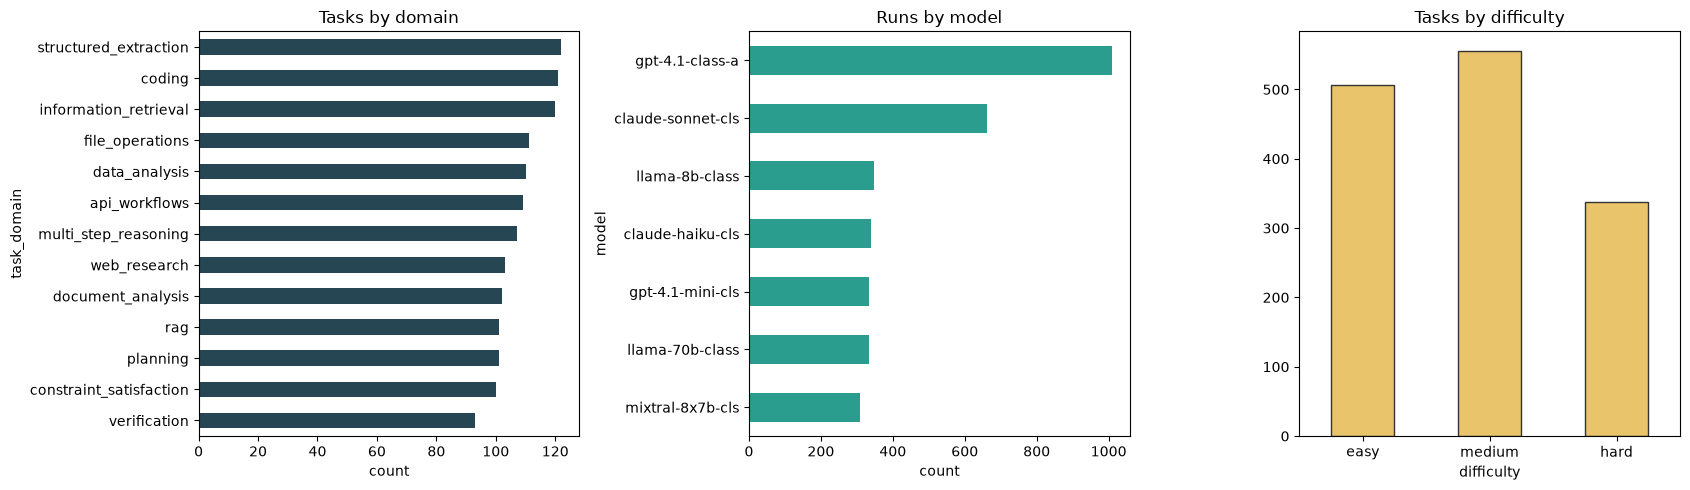

Max single-domain share: 8.7%


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
tasks["task_domain"].value_counts().plot(kind="barh", ax=axes[0], color="#264653")
axes[0].set_title("Tasks by domain")
axes[0].set_xlabel("count")
axes[0].invert_yaxis()

runs.merge(agents, on="agent_id")["model"].value_counts().plot(kind="barh", ax=axes[1], color="#2a9d8f")
axes[1].set_title("Runs by model")
axes[1].set_xlabel("count")
axes[1].invert_yaxis()

tasks["difficulty"].value_counts().reindex(["easy", "medium", "hard"]).plot(kind="bar", ax=axes[2], color="#e9c46a", edgecolor="#333")
axes[2].set_title("Tasks by difficulty")
axes[2].set_xlabel("difficulty")
axes[2].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

print(f"Max single-domain share: {(tasks['task_domain'].value_counts() / len(tasks)).max():.1%}")

## 2. Overall outcome distribution

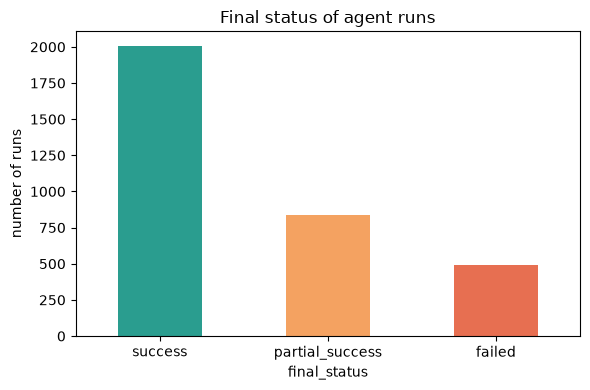

Clean success (no failure at all):      42.0%
Runs that experienced >=1 failure:       58.0%
Runs that experienced >=2 failures:      31.6%  <- multi-failure trajectories, new in v2
Overall task success (incl. recovered):  60.2%


In [4]:
status_counts = runs["final_status"].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
status_counts.plot(kind="bar", ax=ax, color=["#2a9d8f", "#f4a261", "#e76f51"])
ax.set_title("Final status of agent runs")
ax.set_xlabel("final_status")
ax.set_ylabel("number of runs")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

clean_success = ((runs["final_status"] == "success") & (runs["failure_count"] == 0)).mean()
any_failure = (runs["failure_count"] > 0).mean()
multi_failure = (runs["failure_count"] > 1).mean()
print(f"Clean success (no failure at all):      {clean_success:.1%}")
print(f"Runs that experienced >=1 failure:       {any_failure:.1%}")
print(f"Runs that experienced >=2 failures:      {multi_failure:.1%}  <- multi-failure trajectories, new in v2")
print(f"Overall task success (incl. recovered):  {(runs['final_status']=='success').mean():.1%}")

## 3. Failures per trajectory

v1 allowed at most one diagnosed failure per run. v2 removes that cap —
trajectories now show a realistic tapering distribution of 0, 1, 2, 3, or
more failures, not a hard ceiling.

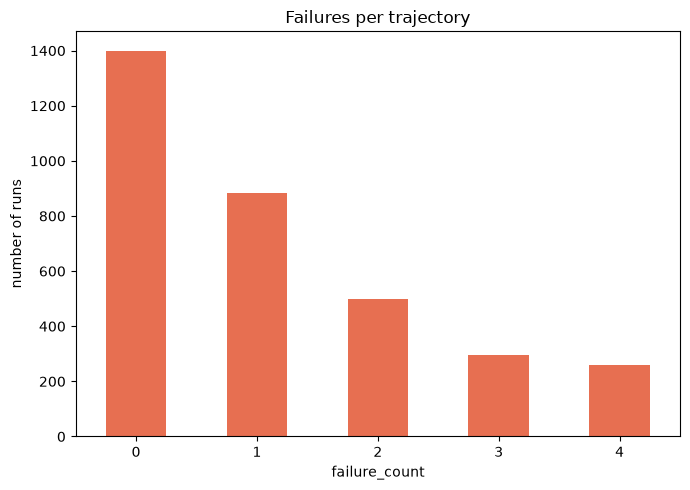

failure_count
0    1400
1     883
2     498
3     297
4     258
Name: count, dtype: int64


In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
runs["failure_count"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#e76f51")
ax.set_title("Failures per trajectory")
ax.set_xlabel("failure_count")
ax.set_ylabel("number of runs")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(runs["failure_count"].value_counts().sort_index())

## 4. Failure cascades

A failure can be the documented cause of a later failure in the same run
(`is_cascading=True`, linked via `parent_failure_id`). This is new in v2
and directly supports research into **failure propagation**.

Cascading failures: 430 (11.3% of all failure events)


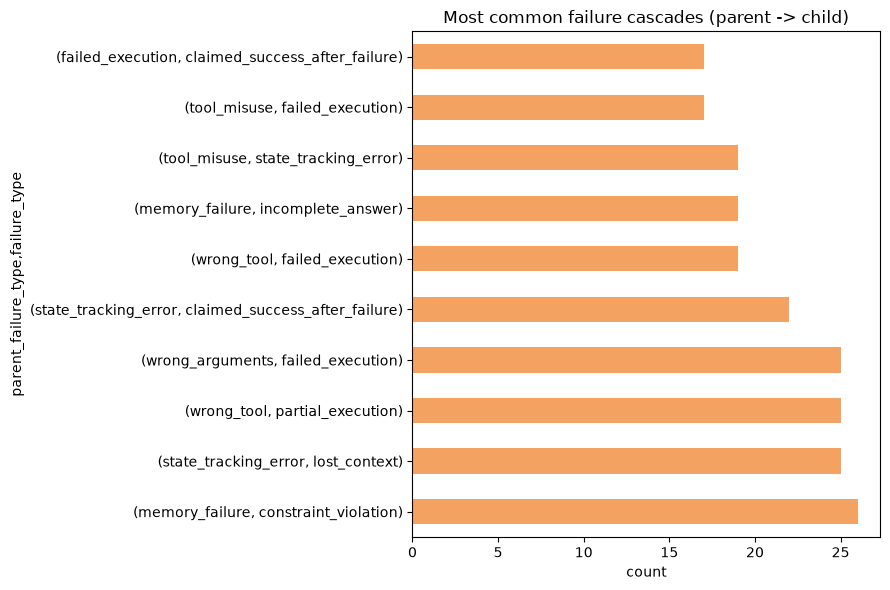

parent_failure_type   failure_type                 
memory_failure        constraint_violation             26
state_tracking_error  lost_context                     25
wrong_tool            partial_execution                25
wrong_arguments       failed_execution                 25
state_tracking_error  claimed_success_after_failure    22
wrong_tool            failed_execution                 19
memory_failure        incomplete_answer                19
tool_misuse           state_tracking_error             19
                      failed_execution                 17
failed_execution      claimed_success_after_failure    17
dtype: int64

In [6]:
n_cascading = failures["is_cascading"].sum()
print(f"Cascading failures: {n_cascading} ({n_cascading / len(failures):.1%} of all failure events)")

cascade_pairs = failures[failures["is_cascading"]].merge(
    failures[["failure_id", "failure_type"]].rename(columns={"failure_id": "parent_failure_id", "failure_type": "parent_failure_type"}),
    on="parent_failure_id",
)
top_pairs = cascade_pairs.groupby(["parent_failure_type", "failure_type"]).size().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(9, 6))
top_pairs.plot(kind="barh", ax=ax, color="#f4a261")
ax.set_title("Most common failure cascades (parent -> child)")
ax.set_xlabel("count")
plt.tight_layout()
plt.show()
top_pairs

## 5. Failures by domain, model, and tool

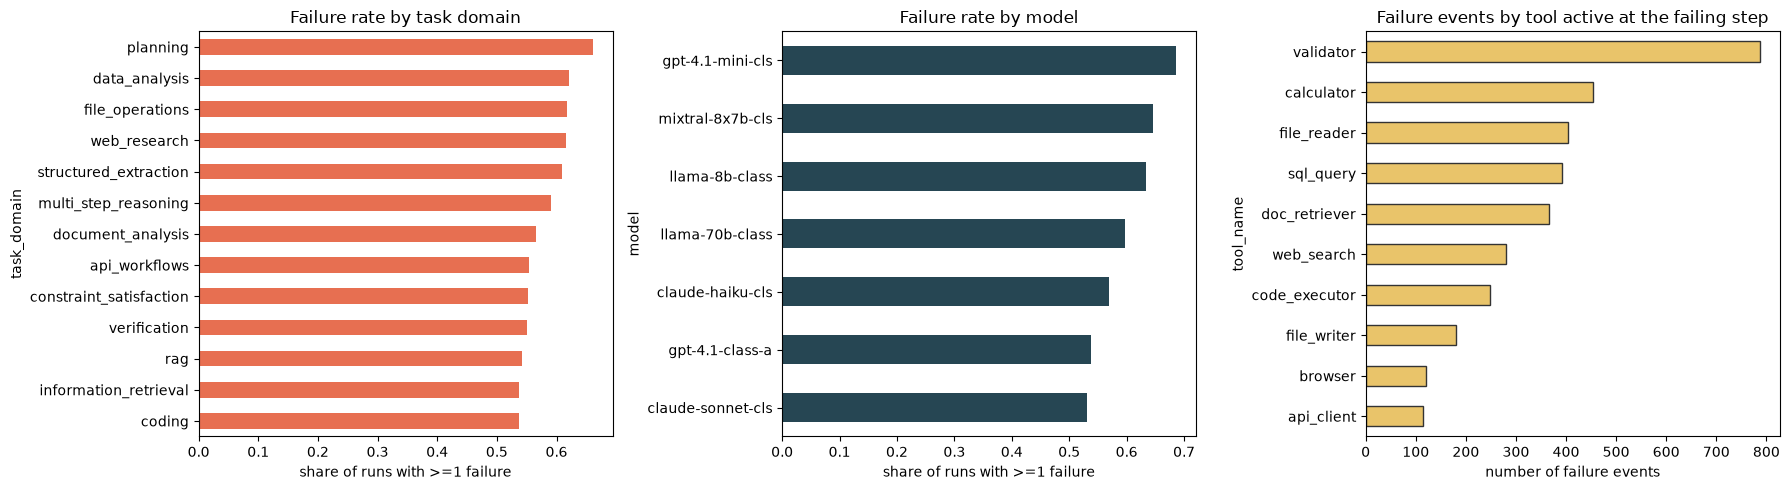

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fail_by_domain = runs.merge(tasks, on="task_id").groupby("task_domain")["failure_count"].apply(lambda s: (s > 0).mean()).sort_values(ascending=False)
fail_by_domain.plot(kind="barh", ax=axes[0], color="#e76f51")
axes[0].set_title("Failure rate by task domain")
axes[0].set_xlabel("share of runs with >=1 failure")
axes[0].invert_yaxis()

fail_by_model = runs.merge(agents, on="agent_id").groupby("model")["failure_count"].apply(lambda s: (s > 0).mean()).sort_values(ascending=False)
fail_by_model.plot(kind="barh", ax=axes[1], color="#264653")
axes[1].set_title("Failure rate by model")
axes[1].set_xlabel("share of runs with >=1 failure")
axes[1].invert_yaxis()

fail_steps = failures.merge(steps[["step_id", "tool_name"]], on="step_id", how="left")
fail_steps["tool_name"].value_counts(dropna=True).plot(kind="barh", ax=axes[2], color="#e9c46a", edgecolor="#333")
axes[2].set_title("Failure events by tool active at the failing step")
axes[2].set_xlabel("number of failure events")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

## 6. Failure taxonomy: category and severity

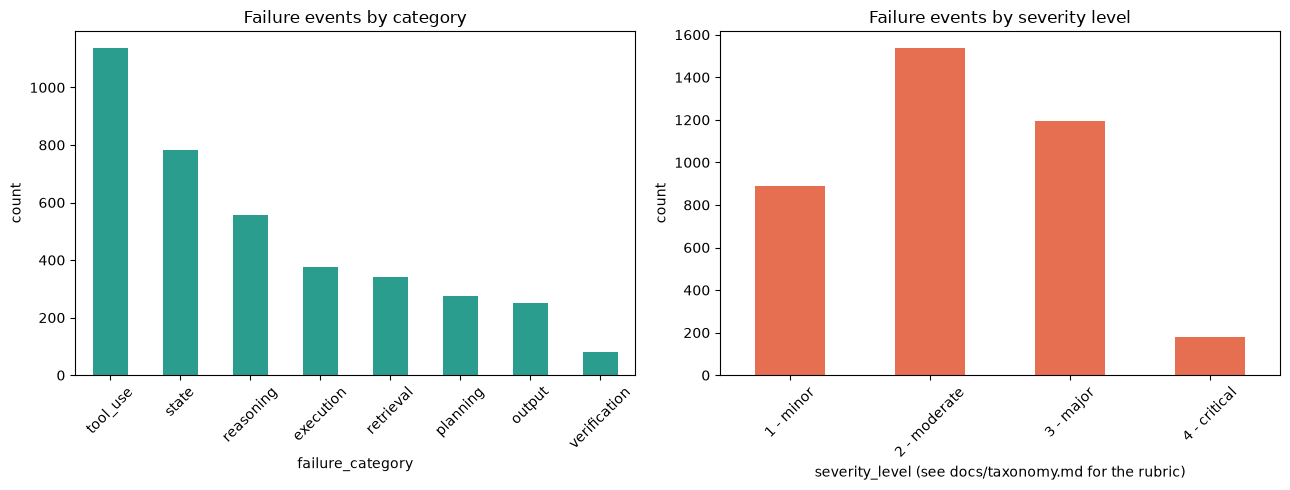

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
failures["failure_category"].value_counts().plot(kind="bar", ax=axes[0], color="#2a9d8f")
axes[0].set_title("Failure events by category")
axes[0].set_xlabel("failure_category")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=45)

severity_labels = {1: "1 - minor", 2: "2 - moderate", 3: "3 - major", 4: "4 - critical"}
failures["severity_level"].map(severity_labels).value_counts().reindex(severity_labels.values()).plot(
    kind="bar", ax=axes[1], color="#e76f51")
axes[1].set_title("Failure events by severity level")
axes[1].set_xlabel("severity_level (see docs/taxonomy.md for the rubric)")
axes[1].set_ylabel("count")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 7. Trajectory length and tool-call distribution

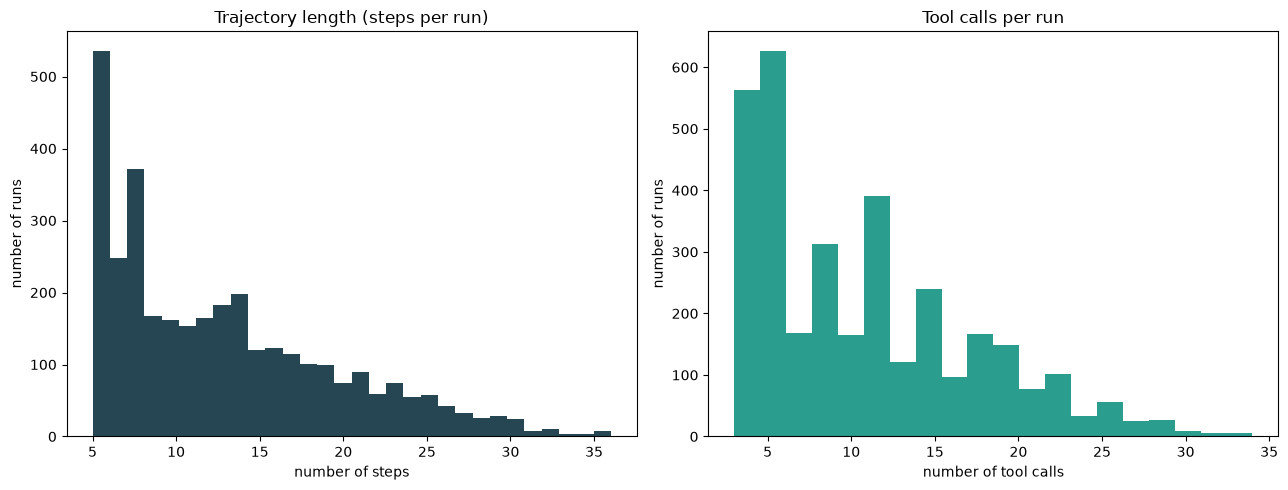

Median trajectory length: 12 steps
Median tool calls per run: 9


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
step_counts = steps.groupby("run_id").size()
axes[0].hist(step_counts, bins=30, color="#264653")
axes[0].set_title("Trajectory length (steps per run)")
axes[0].set_xlabel("number of steps")
axes[0].set_ylabel("number of runs")

axes[1].hist(runs["tool_call_count"], bins=20, color="#2a9d8f")
axes[1].set_title("Tool calls per run")
axes[1].set_xlabel("number of tool calls")
axes[1].set_ylabel("number of runs")
plt.tight_layout()
plt.show()

print(f"Median trajectory length: {step_counts.median():.0f} steps")
print(f"Median tool calls per run: {runs['tool_call_count'].median():.0f}")

## 8. Latency and token cost

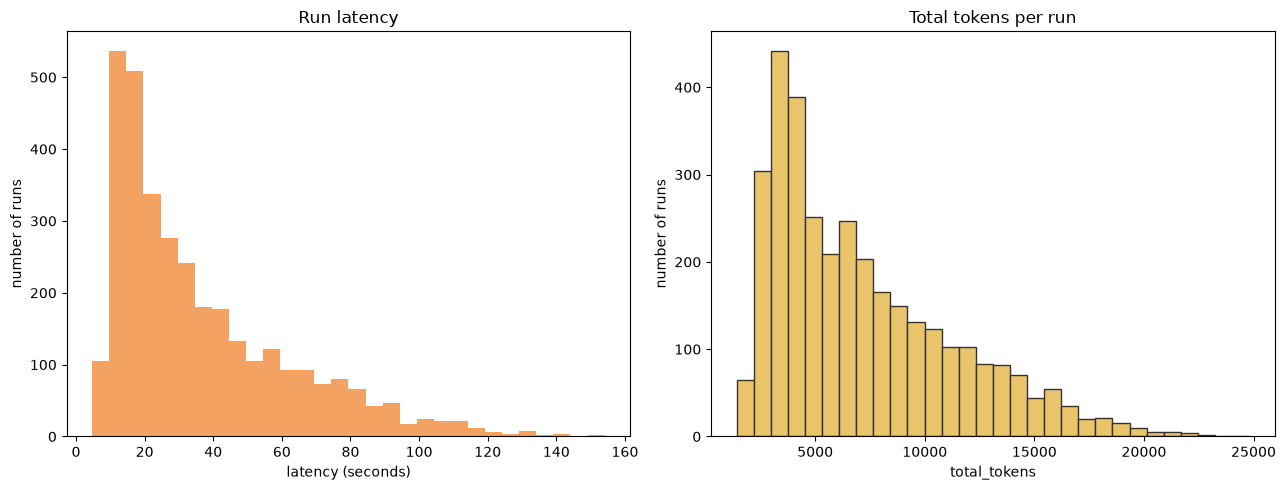

Median latency, successful runs: 19,763 ms
Median latency, non-successful runs: 45,438 ms


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(runs["latency_ms"] / 1000, bins=30, color="#f4a261")
axes[0].set_title("Run latency")
axes[0].set_xlabel("latency (seconds)")
axes[0].set_ylabel("number of runs")

axes[1].hist(runs["total_tokens"], bins=30, color="#e9c46a", edgecolor="#333")
axes[1].set_title("Total tokens per run")
axes[1].set_xlabel("total_tokens")
axes[1].set_ylabel("number of runs")
plt.tight_layout()
plt.show()

failed_runs = runs[runs["final_status"] != "success"]
ok_runs = runs[runs["final_status"] == "success"]
print(f"Median latency, successful runs: {ok_runs['latency_ms'].median():,.0f} ms")
print(f"Median latency, non-successful runs: {failed_runs['latency_ms'].median():,.0f} ms")

## 9. Recovery rate and effectiveness

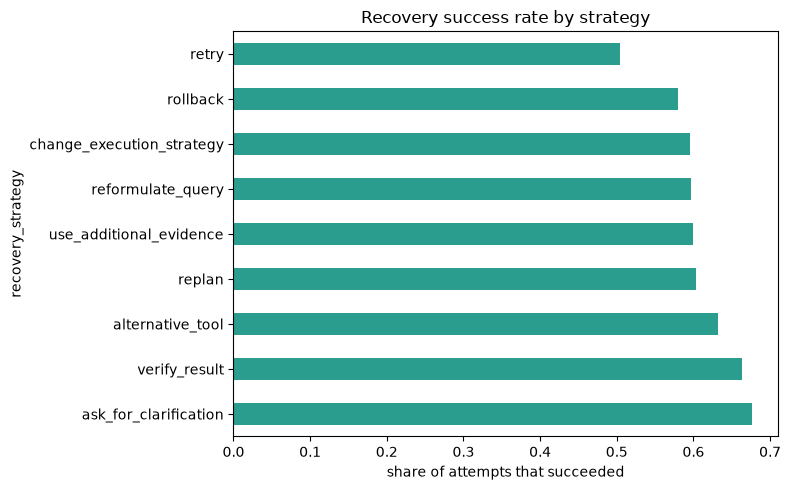

Recovery attempted (of failures): 75.4%
Recovery success rate (per attempt): 60.3%
Repeated recovery attempts (2nd+ try on the same failure): 532


In [11]:
attempted = recoveries[recoveries["recovery_attempted"]]
recovery_by_strategy = attempted.groupby("recovery_strategy")["recovery_success"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
recovery_by_strategy.plot(kind="barh", ax=ax, color="#2a9d8f")
ax.set_title("Recovery success rate by strategy")
ax.set_xlabel("share of attempts that succeeded")
ax.set_ylabel("recovery_strategy")
plt.tight_layout()
plt.show()

print(f"Recovery attempted (of failures): {recoveries.drop_duplicates('failure_id')['recovery_attempted'].mean():.1%}")
print(f"Recovery success rate (per attempt): {attempted['recovery_success'].mean():.1%}")
print(f"Repeated recovery attempts (2nd+ try on the same failure): {(attempted['recovery_attempt_number'] > 1).sum()}")

## 10. Recovery success by failure category and by model

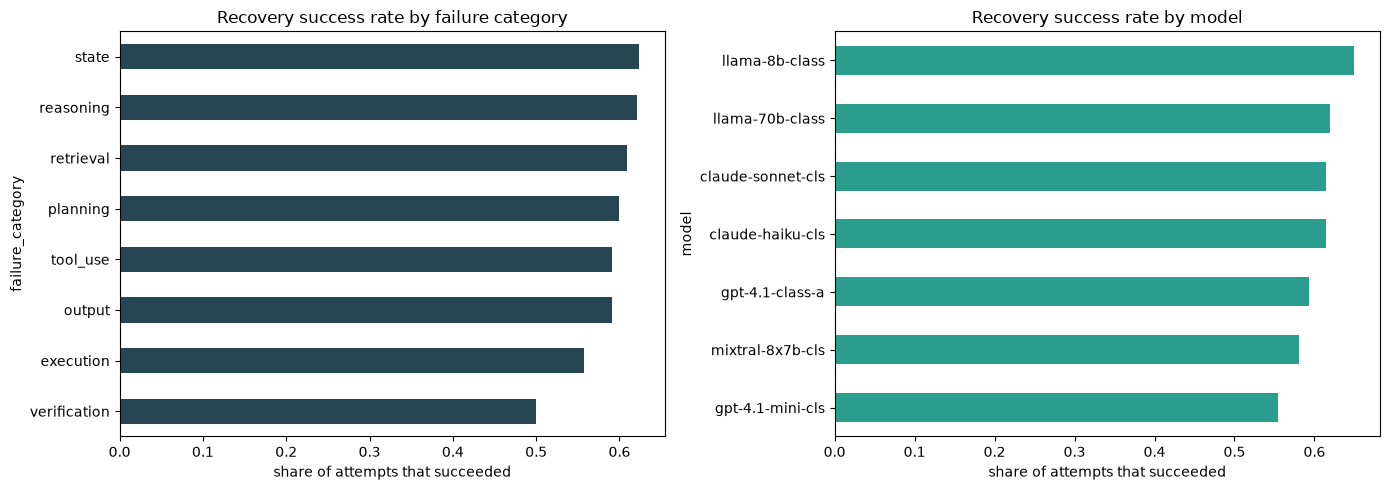

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fail_recov = failures.merge(recoveries, on=["run_id", "failure_id"])
fail_recov_attempted = fail_recov[fail_recov["recovery_attempted"]]
fail_recov_attempted.groupby("failure_category")["recovery_success"].mean().sort_values(ascending=False).plot(
    kind="barh", ax=axes[0], color="#264653")
axes[0].set_title("Recovery success rate by failure category")
axes[0].set_xlabel("share of attempts that succeeded")
axes[0].invert_yaxis()

fail_recov_model = fail_recov_attempted.merge(runs[["run_id", "agent_id"]], on="run_id").merge(agents[["agent_id", "model"]], on="agent_id")
fail_recov_model.groupby("model")["recovery_success"].mean().sort_values(ascending=False).plot(
    kind="barh", ax=axes[1], color="#2a9d8f")
axes[1].set_title("Recovery success rate by model")
axes[1].set_xlabel("share of attempts that succeeded")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 11. Successful vs failed trajectories — reliability score

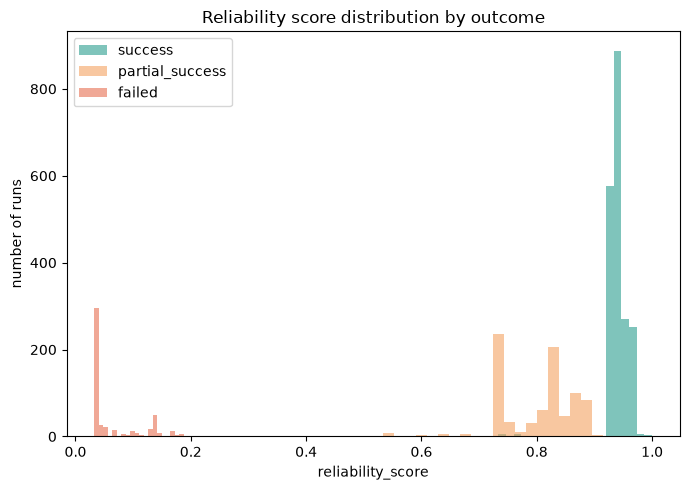

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
for status, color in [("success", "#2a9d8f"), ("partial_success", "#f4a261"), ("failed", "#e76f51")]:
    subset = evaluations[evaluations["run_id"].isin(runs[runs["final_status"] == status]["run_id"])]
    ax.hist(subset["reliability_score"], bins=20, alpha=0.6, label=status, color=color)
ax.set_title("Reliability score distribution by outcome")
ax.set_xlabel("reliability_score")
ax.set_ylabel("number of runs")
ax.legend()
plt.tight_layout()
plt.show()

### Key Findings

1. **Just over half of runs experience at least one failure, and roughly
   a third of ALL runs experience more than one.** Multi-failure
   trajectories (new in v2) are common enough to be a real analytical
   category, not a rare edge case — supporting genuine research into
   failure accumulation within a single run, not just single-failure
   pass/fail modeling.
2. **Failure cascades are a measurable, non-trivial phenomenon.** Around
   one in nine failure events is causally linked to an earlier failure in
   the same run via `parent_failure_id`. The most common cascades run
   from state/tracking problems (`memory_failure`, `state_tracking_error`)
   and tool-use problems (`wrong_tool`, `wrong_arguments`) into downstream
   execution and output failures (`constraint_violation`, `lost_context`,
   `partial_execution`, `failed_execution`) — evidence that failure
   propagation follows the trajectory's actual causal structure (a
   tool/state problem breaks what depends on it downstream), not random
   co-occurrence.
3. **`tool_use` remains the largest single failure category**, but with
   genuine severity spread (see the severity_level rubric in
   `docs/taxonomy.md`, level 1=minor .. 4=critical) — no `tool_use` or
   `state` failure reaches level 4 in this taxonomy, while level-4
   (critical) failures are concentrated entirely in `output` and
   `execution` — exactly the categories where the agent's own signal
   about task state becomes untrustworthy (a hallucinated result, a
   claimed success after failure, an unauthorized action). This
   concentration is by taxonomy design (see `docs/taxonomy.md`
   "Severity rubric"), not an emergent artifact.
4. **Recovery strategies differ meaningfully in effectiveness, and
   repeated attempts are not free.** `ask_for_clarification` and
   `verify_result` show the highest per-attempt success rates; later
   attempts on the same failure succeed less often than the first
   (diminishing returns are built into the generative process and show
   up directly in the data, not just as a documented assumption).
5. **Failure rate varies by domain, difficulty, and model capability
   tier simultaneously** — this is a deliberate v2 change from v1, where
   failure was largely independent of observable features. See
   `notebooks/02_predict_agent_failure.ipynb` for how much predictive
   signal this actually provides.

These findings describe the generative process encoded in this synthetic
benchmark (see `docs/methodology.md`); they are a reproducible testbed for
these questions, not a measurement of real deployed-agent failure rates.